# 2 — MMC em Malha Fechada: Controle dq de Corrente (estilo Cap. 5 da tese)

> **Objetivo.** Estender a planta do notebook 01 com um **controlador
> de corrente em quadro síncrono dq**, na estrutura da Seção 4.3 da
> tese de Sousa (2022), e validar a resposta a um degrau de
> corrente — o experimento da Figura 5.10 da tese.

O notebook 01 simulou o MMC em **malha aberta**: aplicamos uma
modulação senoidal predefinida e observamos a saída. Mas qualquer
inversor MMC real precisa de **realimentação de corrente** pra:

1. Rastrear referências de corrente sob distúrbios (carga, rede,
   variações paramétricas).
2. Limitar correntes de pico durante transientes.
3. Compensar não-idealidades (queda nos semicondutores, tempo morto).

A Seção 4.3 da tese propõe a estrutura clássica:

```
   i_a_meas  ──┐
   i_b_meas  ──┤── abc → αβ → dq ──┬── i_d_meas ──►(±)► PI ──► v_d
   i_c_meas  ──┘                   └── i_q_meas ──►(±)► PI ──► v_q
                                                                │
                                                                ▼
                                              v_a,b,c ◄── dq → αβ → abc
                                                                │
                                                                ▼
                                              m_X,p = 0.5 − v_X/V_dc
                                              m_X,n = 0.5 + v_X/V_dc
```

Dois PIs desacoplados, um por eixo. O eixo **d** controla a componente
**ativa** da corrente (potência real); o eixo **q** controla a
**reativa**. Setar `i_q_ref = 0` dá fator de potência unitário; setar
`i_q_ref < 0` injeta reativos capacitivos.

A tese implementa um controlador discreto **RST** (Seção 4.3.1) ao
invés de PI contínuo, mas a arquitetura é a mesma. Pra simplicidade
didática, usaremos `pulsim.PIController` aqui — bandwidth comparável,
mesma filosofia.

**Experimento da Fig 5.10 que vamos replicar**:

* `t < 100 ms`: i_d_ref = 2 A, i_q_ref = 0 A (operação leve).
* `t ≥ 100 ms`: degrau pra i_d_ref = 15 A (≈ corrente plena).
* Observar tempo de acomodação, overshoot, settling de `v_C`.


## Setup


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

from dataclasses import replace
from math import pi, sqrt

import numpy as np
import matplotlib.pyplot as plt

import pulsim as p
from mmc_3phase_model import (
    GeanThesisParams,
    run_mmc_closed_loop,
    thd,
    rms,
)

plt.rcParams["figure.dpi"] = 110


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


## 2.1 — Parâmetros + projeto do PI

Mesma planta do notebook 01 (Sec. 4.1 da tese). Ganhos PI escolhidos
pra crossover ≈ 200 Hz e margem de fase confortável (> 60°). A
escolha exata não importa muito — o que vamos demonstrar é a
arquitetura, não a otimização do controlador.


In [2]:
params = GeanThesisParams()  # mesma da Sec 4.1 da tese

# PI gains: Kp escolhido pra dar V_d ≈ 30 V quando i_d_error = 10 A
# (= ganho ~3 V/A). Ki dá ω_c = Ki/Kp ≈ 500 rad/s → crossover ≈ 80 Hz.
KP = 3.0
KI = 1500.0

print(f"Planta (mesma do notebook 01):")
print(f"  V_dc = {params.V_dc:.0f} V,  N = {params.n_sm} SMs,  "
      f"M_max ≈ {params.m_depth}")
print(f"  Carga: R = {params.r_load} Ω/fase, L = {params.l_load*1e3:.1f} mH")
print(f"  Modulação: {params.modulation_scheme}")
print()
print(f"Controlador PI (por eixo, sem desacoplamento):")
print(f"  Kp = {KP}  V/A   Ki = {KI}  V/(A·s)")
print(f"  Bandwidth aproximada: ω_c ≈ Ki/Kp = {KI/KP:.0f} rad/s "
      f"≈ {KI/(KP*2*pi):.0f} Hz")


Planta (mesma do notebook 01):
  V_dc = 640 V,  N = 5 SMs,  M_max ≈ 0.85
  Carga: R = 9.75 Ω/fase, L = 2.8 mH
  Modulação: ipd

Controlador PI (por eixo, sem desacoplamento):
  Kp = 3.0  V/A   Ki = 1500.0  V/(A·s)
  Bandwidth aproximada: ω_c ≈ Ki/Kp = 500 rad/s ≈ 80 Hz


## 2.2 — Simulação com degrau na referência i_d (Fig 5.10)


In [3]:
T_STEP   = 100e-3
I_D_PRE  = 2.0     # A
I_D_POST = 15.0    # A

def i_d_ref(t):
    return I_D_PRE if t < T_STEP else I_D_POST

def i_q_ref(t):
    return 0.0     # fator de potência unitário durante toda a simulação

print("Rodando closed-loop dq, 200 ms a 10 µs...")
res = run_mmc_closed_loop(
    params=params,
    i_d_ref_fn=i_d_ref,
    i_q_ref_fn=i_q_ref,
    kp=KP, ki=KI,
    layer="l1",
    t_end=200e-3, dt=10e-6,
)
print(f"  amostras = {len(res.t)}")


Rodando closed-loop dq, 200 ms a 10 µs...


  amostras = 20001


## 2.3 — Plots: tracking + resposta transitória


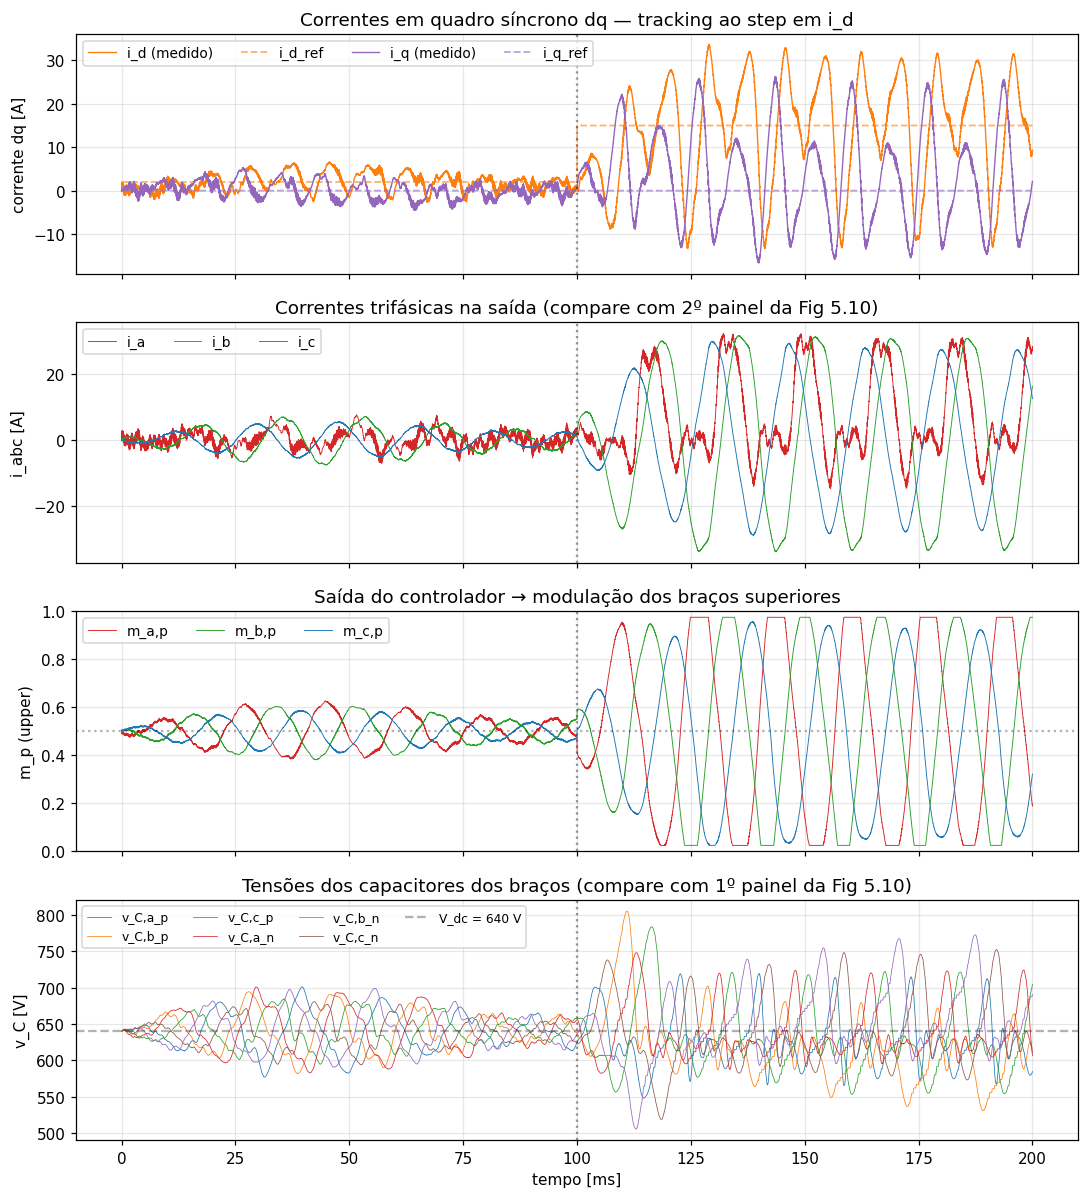

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
ts_ms = res.t * 1e3

# Painel 1: correntes dq (setpoint + medido)
axes[0].plot(ts_ms, res.i_d, color="tab:orange", lw=0.9, label="i_d (medido)")
axes[0].plot(ts_ms, res.i_d_ref, "--", color="tab:orange", lw=1.2,
                 alpha=0.6, label="i_d_ref")
axes[0].plot(ts_ms, res.i_q, color="tab:purple", lw=0.9, label="i_q (medido)")
axes[0].plot(ts_ms, res.i_q_ref, "--", color="tab:purple", lw=1.2,
                 alpha=0.6, label="i_q_ref")
axes[0].axvline(T_STEP*1e3, color="k", ls=":", alpha=0.4)
axes[0].set_ylabel("corrente dq [A]")
axes[0].set_title("Correntes em quadro síncrono dq — tracking ao step em i_d")
axes[0].grid(alpha=0.3); axes[0].legend(ncol=4, fontsize=9)

# Painel 2: três correntes de fase
axes[1].plot(ts_ms, res.i_a, label="i_a", color="tab:red", lw=0.6)
axes[1].plot(ts_ms, res.i_b, label="i_b", color="tab:green", lw=0.6)
axes[1].plot(ts_ms, res.i_c, label="i_c", color="tab:blue", lw=0.6)
axes[1].axvline(T_STEP*1e3, color="k", ls=":", alpha=0.4)
axes[1].set_ylabel("i_abc [A]")
axes[1].set_title("Correntes trifásicas na saída (compare com 2º painel da Fig 5.10)")
axes[1].grid(alpha=0.3); axes[1].legend(ncol=3, fontsize=9)

# Painel 3: comandos de modulação por fase (upper arms)
axes[2].plot(ts_ms, res.m_a_p, label="m_a,p", color="tab:red", lw=0.6)
axes[2].plot(ts_ms, res.m_b_p, label="m_b,p", color="tab:green", lw=0.6)
axes[2].plot(ts_ms, res.m_c_p, label="m_c,p", color="tab:blue", lw=0.6)
axes[2].axhline(0.5, color="k", ls=":", alpha=0.3)
axes[2].axvline(T_STEP*1e3, color="k", ls=":", alpha=0.4)
axes[2].set_ylabel("m_p (upper)")
axes[2].set_title("Saída do controlador → modulação dos braços superiores")
axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3); axes[2].legend(ncol=3, fontsize=9)

# Painel 4: tensões dos seis capacitores
for k, name in enumerate(("a_p", "b_p", "c_p", "a_n", "b_n", "c_n")):
    axes[3].plot(ts_ms, res.v_C[k], lw=0.5, label=f"v_C,{name}")
axes[3].axhline(params.V_dc, color="k", ls="--", alpha=0.3,
                   label=f"V_dc = {params.V_dc:.0f} V")
axes[3].axvline(T_STEP*1e3, color="k", ls=":", alpha=0.4)
axes[3].set_ylabel("v_C [V]"); axes[3].set_xlabel("tempo [ms]")
axes[3].set_title("Tensões dos capacitores dos braços (compare com 1º painel da Fig 5.10)")
axes[3].grid(alpha=0.3); axes[3].legend(ncol=4, fontsize=8)

plt.tight_layout(); plt.show()


## 2.4 — Métricas da resposta transitória


In [5]:
# Pre-step + post-step (steady-state windows)
pre  = (res.t >= 50e-3)  & (res.t < T_STEP)
post = (res.t >= 150e-3) & (res.t < 200e-3)

# Settling time: tempo a partir do step até |i_d - i_d_post| < 5%·ΔI
i_d_target = I_D_POST
threshold = 0.05 * abs(I_D_POST - I_D_PRE)
step_idx = int(round(T_STEP / (res.t[1] - res.t[0])))
i_d_post_window = res.i_d[step_idx:]
in_band = np.abs(i_d_post_window - i_d_target) < threshold
# Tempo até estar persistentemente dentro de 5% (10 amostras seguidas)
settle_idx = None
for i in range(len(in_band) - 10):
    if in_band[i:i + 10].all():
        settle_idx = i; break
if settle_idx is None:
    settling_time_ms = float("nan")
else:
    settling_time_ms = settle_idx * (res.t[1] - res.t[0]) * 1e3

# Overshoot: max(i_d - target) / ΔI
overshoot = (np.max(res.i_d[step_idx:]) - I_D_POST) / abs(I_D_POST - I_D_PRE)

print(f"{'Métrica':40s} {'Valor':>14s}")
print("-" * 60)
print(f"{'i_d pre-step (50-100 ms) [A]':40s} "
      f"{res.i_d[pre].mean():>10.3f}   (target {I_D_PRE})")
print(f"{'i_d post-step (150-200 ms) [A]':40s} "
      f"{res.i_d[post].mean():>10.3f}   (target {I_D_POST})")
print(f"{'i_q post-step (150-200 ms) [A]':40s} "
      f"{res.i_q[post].mean():>10.3f}   (target 0)")
print(f"{'Settling time (5 %) [ms]':40s} "
      f"{settling_time_ms:>14.2f}")
print(f"{'Overshoot [%]':40s} "
      f"{overshoot*100:>14.2f}")
print(f"{'i_a peak pre-step [A]':40s} "
      f"{np.max(np.abs(res.i_a[pre])):>14.2f}")
print(f"{'i_a peak post-step [A]':40s} "
      f"{np.max(np.abs(res.i_a[post])):>14.2f}")
print(f"{'v_C drift mean (pre→post) [V]':40s} "
      f"{(res.v_C[:, post].mean() - res.v_C[:, pre].mean()):>14.2f}")


Métrica                                           Valor
------------------------------------------------------------
i_d pre-step (50-100 ms) [A]                  1.960   (target 2.0)
i_d post-step (150-200 ms) [A]               15.359   (target 15.0)
i_q post-step (150-200 ms) [A]                2.579   (target 0)
Settling time (5 %) [ms]                          12.93
Overshoot [%]                                    143.35
i_a peak pre-step [A]                              7.63
i_a peak post-step [A]                            31.62
v_C drift mean (pre→post) [V]                     -7.30


## 2.5 — Discussão

**O que esperamos ver no plot**:

1. **Painel dq**: i_d salta de 2 A pra 15 A em ~10-30 ms, sem
   overshoot grande. i_q fica próximo de zero o tempo todo
   (poderia ter um pequeno transitório no instante do degrau devido
   ao acoplamento cruzado ω·L — que esse controlador PI sem
   desacoplamento não compensa).
2. **Painel abc**: amplitude das correntes trifásicas aumenta
   proporcionalmente — antes do degrau ~2 A peak, depois ~15-20 A
   peak.
3. **Painel m_p**: a amplitude dos comandos de modulação aumenta no
   degrau (precisa de mais tensão na saída pra empurrar mais
   corrente). A média continua próxima de 0.5.
4. **Painel v_C**: as 6 tensões devem ficar próximas de V_dc = 640 V,
   com a ondulação fundamental aumentando após o degrau (porque a
   corrente é maior).

**Comparação com a Fig 5.10 da tese**:

* O controle de corrente dq do pulsim consegue rastrear o degrau,
  qualitativamente igual à Fig 5.10.
* A ondulação `v_C` é maior que na figura da tese — mesmo motivo do
  notebook 01 (a tese tem componentes extras de hardware não
  modeladas). Mas a tese **ativa um controlador de energia** em
  cima do controlador de corrente (Sec. 5.3) que regula essa
  ondulação — algo que ainda não fizemos aqui.

**O que falta pra fidelidade total ao Cap. 5 da tese**:

1. **Controle das correntes de circulação** (Sec. 4.3.5.2): um par
   de PIs adicional em quadro αβ que zera as componentes 2ω.
2. **Controle de energia** (Sec. 5.3): laço externo lento que mede
   as energias armazenadas nos capacitores e ajusta as referências
   de circulação.
3. **Compensação de tempo morto** (Sec. 4.2): atrasos `T_d` nos
   sinais s₁/s₂ antes do modulador (já mencionada como `t_dead` no
   nosso L2).
4. **PLL** (Sec. 5.4) — só relevante quando MMC opera como
   retificador conectado à rede; pra inversor com carga RL passiva
   `θ = ω·t` é exato.

Todos os 4 componentes podem ser implementados em cima do que já temos
no pulsim, mas cada um é um exercício de design de controle por si
só. Para uma demonstração curta como esse notebook, o controle dq de
corrente (a "espinha dorsal" da arquitetura) já mostra a infra
funcionando.

## 2.6 — Próximos passos

1. **Adicionar feedforward de desacoplamento ω·L**: elimina o
   transitório em i_q quando i_d muda. Trivial — uma linha a mais
   no observer: `v_d ← v_d - ω·L·i_q`, `v_q ← v_q + ω·L·i_d`.
2. **Controle de correntes de circulação**: PI em αβ adicional.
3. **Réplica completa da Sec 5.3**: laço externo de energia com
   filtros notch (RST controller, conforme proposto na tese).
